In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data (1).csv to data (1).csv


In [ ]:
df = pd.read_csv("data (1).csv")

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
print(df.shape)

df.info()

(569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

In [ ]:
df = df.drop(["id", "Unnamed: 32"], axis=1)

In [ ]:
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
n_features = X_train.shape[1]

weights = np.zeros(n_features)

bias = 0

In [ ]:
def predict(X, weights, bias):

    return np.dot(X, weights) + bias

In [ ]:
def compute_cost(y_true, y_pred):

    m = len(y_true)

    cost = (1/m) * np.sum((y_true - y_pred)**2)

    return cost

In [ ]:
def compute_gradients(
        X,
        y,
        y_pred):

    m = len(y)

    dw = (-2/m) * np.dot(
        X.T,
        (y - y_pred)
    )

    db = (-2/m) * np.sum(
        y - y_pred
    )

    return dw, db

In [ ]:
def gradient_descent(
        X,
        y,
        weights,
        bias,
        learning_rate,
        iterations):

    costs = []

    for i in range(iterations):

        y_pred = predict(
            X,
            weights,
            bias
        )

        cost = compute_cost(
            y,
            y_pred
        )

        dw, db = compute_gradients(
            X,
            y,
            y_pred
        )

        weights = weights - learning_rate * dw

        bias = bias - learning_rate * db

        costs.append(cost)

    return weights, bias, costs

In [ ]:
learning_rate = 0.01

iterations = 1000

In [ ]:
weights, bias, costs = gradient_descent(
    X_train,
    y_train,
    weights,
    bias,
    learning_rate,
    iterations
)

In [ ]:
print(costs[:10])

[np.float64(0.37142857142857144), np.float64(0.2983425964156276), np.float64(0.2551631419185304), np.float64(0.22855719944889089), np.float64(0.2112125642263855), np.float64(0.19911058967451775), np.float64(0.19003569763479622), np.float64(0.1827605223038948), np.float64(0.1766002078061154), np.float64(0.1711684500134225)]


In [ ]:
print(costs[-10:])

[np.float64(0.0552998181873101), np.float64(0.05529711845471949), np.float64(0.05529442273994744), np.float64(0.055291731034200445), np.float64(0.055289043328710645), np.float64(0.05528635961473575), np.float64(0.05528367988355896), np.float64(0.05528100412648884), np.float64(0.055278332334859265), np.float64(0.055275664500029284)]


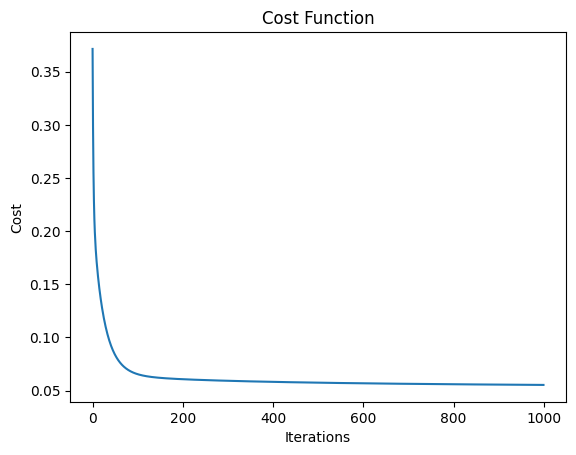

In [ ]:
plt.plot(costs)

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.title("Cost Function")

plt.show()

In [ ]:
y_pred = predict(
    X_test,
    weights,
    bias
)

In [ ]:
y_pred_class = np.where(
    y_pred >= 0.5,
    1,
    0
)

In [ ]:
accuracy = np.mean(
    y_pred_class == y_test
)

print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


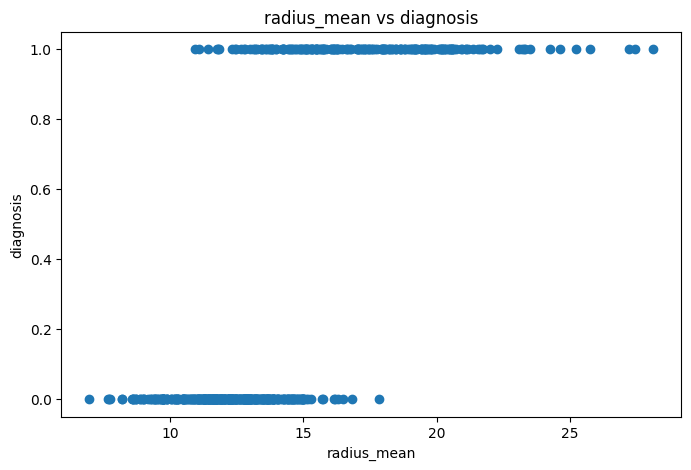

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["radius_mean"], df["diagnosis"])

plt.xlabel("radius_mean")
plt.ylabel("diagnosis")

plt.title("radius_mean vs diagnosis")

plt.show()

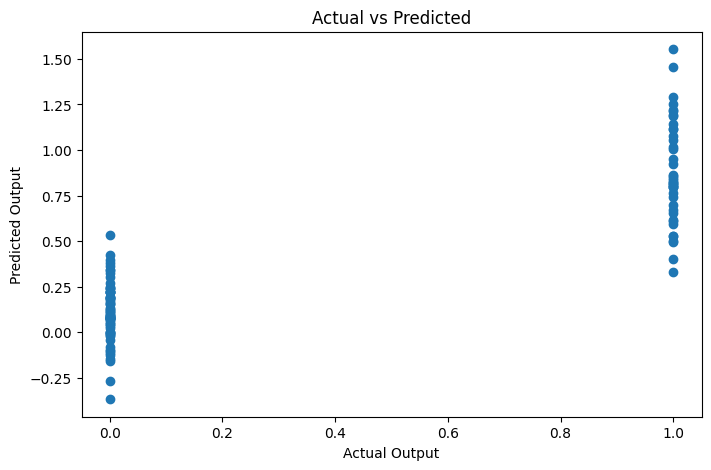

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")

plt.title("Actual vs Predicted")

plt.show()